In [ ]:
from google.colab import files
uploaded = files.upload()

Saving anlsysis.pkl to anlsysis.pkl


In [ ]:
import pandas as pd
from google.colab import drive
drive.mount('/content/drive')

final_df = pd.read_pickle('/content/drive/MyDrive/analysis.pkl')



Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
final_df.columns

Index(['SeniorCitizen', 'Partner', 'Dependents', 'tenure', 'PhoneService',
       'PaperlessBilling', 'MonthlyCharges', 'TotalCharges', 'gender_Female',
       'MultipleLines_No', 'MultipleLines_Yes', 'InternetService_DSL',
       'InternetService_Fiber optic', 'OnlineSecurity_No',
       'OnlineSecurity_Yes', 'OnlineBackup_No', 'OnlineBackup_Yes',
       'DeviceProtection_No', 'DeviceProtection_Yes', 'TechSupport_No',
       'TechSupport_Yes', 'StreamingTV_No', 'StreamingTV_Yes',
       'StreamingMovies_No', 'StreamingMovies_Yes', 'Contract_Month-to-month',
       'Contract_One year', 'PaymentMethod_Bank transfer (automatic)',
       'PaymentMethod_Credit card (automatic)',
       'PaymentMethod_Electronic check', 'Churn'],
      dtype='object')

In [ ]:
final_df.to_csv("project1_clean_data.csv", index=False)


In [ ]:
from sklearn.model_selection import train_test_split
X=final_df[['SeniorCitizen', 'Partner', 'Dependents', 'tenure', 'PhoneService',
       'PaperlessBilling', 'MonthlyCharges', 'TotalCharges', 'gender_Female',
       'MultipleLines_No', 'MultipleLines_Yes', 'InternetService_DSL',
       'InternetService_Fiber optic', 'OnlineSecurity_No',
       'OnlineSecurity_Yes', 'OnlineBackup_No', 'OnlineBackup_Yes',
       'DeviceProtection_No', 'DeviceProtection_Yes', 'TechSupport_No',
       'TechSupport_Yes', 'StreamingTV_No', 'StreamingTV_Yes',
       'StreamingMovies_No', 'StreamingMovies_Yes', 'Contract_Month-to-month',
       'Contract_One year', 'PaymentMethod_Bank transfer (automatic)',
       'PaymentMethod_Credit card (automatic)',
       'PaymentMethod_Electronic check']]
Y=final_df['Churn']
X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size=0.2, random_state=42)

In [ ]:
len(X_train)

5625

In [ ]:
from sklearn.linear_model import LogisticRegression
clf=LogisticRegression(max_iter=6000)
clf.fit(X_train,Y_train)

LogisticRegression(max_iter=6000)

In [ ]:
Y_pred=clf.predict(X_test)
Y_pred

array([0, 0, 1, ..., 0, 0, 0])

In [ ]:
from sklearn.metrics import r2_score
r2_score(Y_test,Y_pred)

-0.08891344974142057

In [ ]:
clf.score(X_test,Y_test)

0.7874911158493249

In [ ]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

In [ ]:
cm=confusion_matrix(Y_test,Y_pred)
cm

array([[914, 119],
       [180, 194]])

In [ ]:
label=clf.classes_

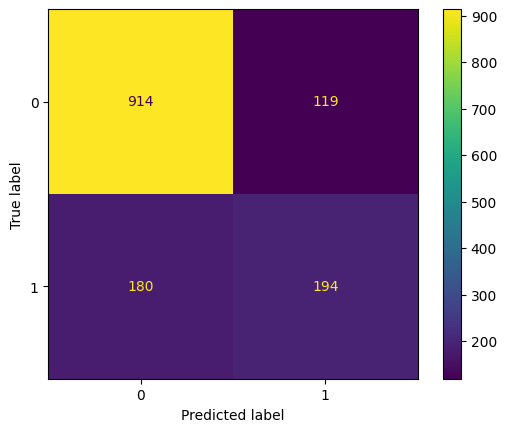

In [ ]:
import matplotlib.pyplot as plt
cm=confusion_matrix(Y_test,Y_pred)
display=ConfusionMatrixDisplay(confusion_matrix=cm,display_labels=label)
display.plot()
#plt.title("Confusion Matrix")
plt.show()

In [ ]:
tn, fp, fn, tp = cm.ravel()
print(f"True Negatives (TN): {tn}")
print(f"False Positives (FP): {fp}")
print(f"False Negatives (FN): {fn}")
print(f"True Positives (TP): {tp}")

True Negatives (TN): 914
False Positives (FP): 119
False Negatives (FN): 180
True Positives (TP): 194


In [ ]:
import pandas as pd

cm_df = pd.DataFrame(
    cm,
    index=["Actual No", "Actual Yes"],
    columns=["Predicted No", "Predicted Yes"]
)

cm_df


,Predicted No,Predicted Yes
Actual No,914,119
Actual Yes,180,194


In [ ]:
project1_output = X_test.copy()
project1_output["Actual_Churn"] = Y_test.values
project1_output["Predicted_Churn"] = Y_pred

project1_output.to_csv("project1_predictions.csv", index=False)


In [ ]:
from sklearn.metrics import classification_report
print(classification_report(Y_test,Y_pred))

              precision    recall  f1-score   support

           0       0.84      0.88      0.86      1033
           1       0.62      0.52      0.56       374

    accuracy                           0.79      1407
   macro avg       0.73      0.70      0.71      1407
weighted avg       0.78      0.79      0.78      1407



In [ ]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

metrics_df = pd.DataFrame([{
    "Accuracy": accuracy_score(Y_test, Y_pred),
    "Precision": precision_score(Y_test, Y_pred),
    "Recall": recall_score(Y_test, Y_pred),
    "F1_Score": f1_score(Y_test, Y_pred)
}])

metrics_df.to_csv("project1_metrics.csv", index=False)


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

final_df.to_pickle('/content/drive/MyDrive/final_df.pkl')


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
project2_df = pd.read_csv("project1_clean_data.csv")


# ===================================================

# PROJECT 2: AI MODEL PERFORMANCE & TRUST EVALUATION

# ==================================================

In Project 1, a customer churn prediction model was built and evaluated using metrics such as accuracy, precision, recall, and a confusion matrix

In this project, the focus is not to building a new model or changing the dataset
Instead, the focus is to understand how much we can rely on the existing model and whether it can be trusted for real business decisions
This project analyzes the model’s mistakes, especially cases where churn customers are missed, and studies the impact of these errors for better business decision
Additional evaluation techniques such as recall prioritization and cost-based analysis are used to better understand the model’s performance
The main goal of this project is to decide how the model should be used in practice and whether it is safe to rely on it for predicting customer churn  

# #######  Decision Threshold Adjustment




In [ ]:
y_probability = clf.predict_proba(X_test)[:, 1]
y_probability

array([0.00556881, 0.1243638 , 0.68671799, ..., 0.09573185, 0.25228192,
       0.00205774])

In [ ]:
y_predct_40 = (y_probability >= 0.40).astype(int)


In [ ]:
from sklearn.metrics import confusion_matrix, classification_report
cm2=confusion_matrix(Y_test,y_predct_40)
cm2

array([[857, 176],
       [132, 242]])

In [ ]:
project2_output = X_test.copy()
project2_output["Actual_Churn"] = Y_test.values
project2_output["Churn_Probability"] = y_predct_40

project2_output.to_csv("project2_model_comparison.csv", index=False)


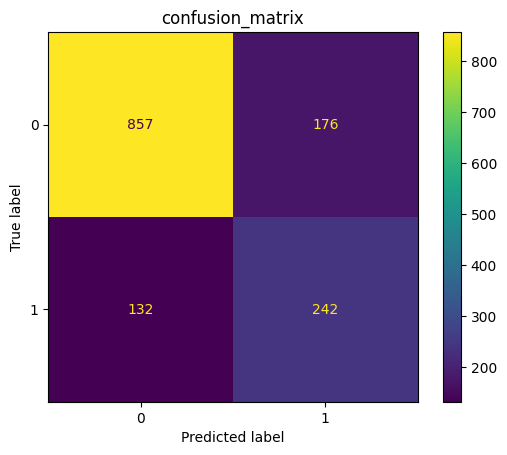

In [ ]:
from sklearn.metrics import confusion_matrix
from matplotlib import pyplot as plt
label=clf.classes_
cm2=confusion_matrix(Y_test,y_predct_40)
display=ConfusionMatrixDisplay(confusion_matrix=cm2,display_labels=label)
display.plot()
plt.title("confusion_matrix")
plt.show()



In [ ]:
from sklearn.metrics import classification_report
print(classification_report(Y_test,y_predct_40))


              precision    recall  f1-score   support

           0       0.87      0.83      0.85      1033
           1       0.58      0.65      0.61       374

    accuracy                           0.78      1407
   macro avg       0.72      0.74      0.73      1407
weighted avg       0.79      0.78      0.78      1407



In [ ]:
from sklearn.metrics import precision_score, recall_score

metrics_project2 = pd.DataFrame({
    "Precision": [
        precision_score(Y_test, y_predct_40)
    ],
    "Recall": [
        recall_score(Y_test, y_predct_40)
    ]
})

metrics_project2.to_csv("project2_threshold_metrics.csv", index=False)


In [ ]:
tn, fp, fn, tp=cm2.ravel()
print(f"False positive is(FP):{fp}")
print(f"False negavtive is(Fn):{fn}")
print(f"True negavtive is(tn):{tn}")
print(f"True psoitive is(tn):{tp}")



False positive is(FP):176
False negavtive is(Fn):132
True negavtive is(tn):857
True psoitive is(tn):242


In [ ]:
import pandas as pd

cm_dff = pd.DataFrame(
    cm2,
    index=["Actual No", "Actual Yes"],
    columns=["Predicted No", "Predicted Yes"]
)

cm_dff


,Predicted No,Predicted Yes
Actual No,857,176
Actual Yes,132,242


 The decision thresholdwas lowered from 0.5 to 0.4.This increased recall, allowing the model to identify more customers likely to churn

#-----------   Cost-Based Business Evaluation----------
#Converting mistakes -> Costs
Missed churn->false negative
Cost=$10000

Uncessarly warned->false positive
Cost=$1000

In [ ]:
"""before decision threshold adujstment
False Negatives = 180
False Positives = 119"""
fn_cost = 180 * 10000
fp_cost = 119 * 1000

total_cost = fn_cost + fp_cost
print(f"$ {total_cost}")


$ 1919000


In [ ]:
"""Use new confusion matrix values after threshold = 0.40.
false negative=132
false positive=176"""
fn_cost=132*10000
fp_cost=176*1000

total_cost=fn_cost+fp_cost
print(f"$ {total_cost}")

$ 1496000


Default threshold -> Higher
Reduced threshold -> Lower
# The threshold-adjusted model resulted in lower overall business loss, making it a safer choice for real-world usage

In [ ]:
from google.colab import files

files.download("project1_predictions.csv")


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
from google.colab import files

files.download("project1_metrics.csv")




<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
from google.colab import files


files.download("project2_threshold_metrics.csv")


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>